# Share-Shuffle 🔀
### Do companies that issue stock underperform the ones buying it back?

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Issuance anomaly on large caps?: Not supported](https://img.shields.io/badge/Issuance_anomaly_on_large_caps%3F-Not_supported-8b949e?style=flat-square)

The textbook anomaly: firms that print new shares go on to lag, firms that buy back their own stock go on to win. It's one of the best-documented effects in academic finance. So we built it on real SEC filings for the S&P 500 — and it ran **backwards**. The big *issuers* (+22.8%/yr) actually *beat* the buyback names (+20.0%).

> 📓 **Plain-language layer.** The long-short, the backwards sign, and the small-cap explanation are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every number is generated by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))  # repo root (quantlab/)
sys.path.insert(0, os.path.abspath(".."))        # study package (share_shuffle/)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5); plt.rcParams["axes.grid"] = True
import numpy as np, pandas as pd
from share_shuffle import data, strategy as st
sig, fwd = data.fetch_panel()                  # cache-first (shared EDGAR pull)
h = st.quantile_hedge(sig, fwd, q=0.2, long_high=False)   # long low-issuance / buyback


## The answer first 🎯

| The question | The data (~412 S&P names, ~2010–2025) |
|---|---|
| "Do issuers underperform buyback firms?" | No — they **beat** them by ~3%/yr here. |
| "Is the famous anomaly tradable on large caps?" | No: hedge **−2.8%/yr, Sharpe −0.30**. |
| "So where is the real effect?" | In small caps — the wrong universe for a free EDGAR pull. |

## 1 · The claim

Net share issuance — the year-on-year change in shares outstanding — negatively predicts returns (Pontiff & Woodgate 2008; Daniel & Titman 2006). Issue stock, underperform; retire stock, outperform. The folk version: *buybacks are a vote of confidence, dilution is a warning.*

## 2 · So what?

If true and tradable, you'd tilt toward the disciplined cannibals and away from the diluters — a clean fundamental signal you can pull straight from 10-K filings for free. The question is whether it survives on the names you can actually trade in size.

## 3 · How would we even know?

Pull diluted shares outstanding from EDGAR for the S&P 500, compute each firm's net issuance, sort every year, go long the bottom-20% (buyers) and short the top-20% (issuers), and measure next year's hedge return over the XBRL era.

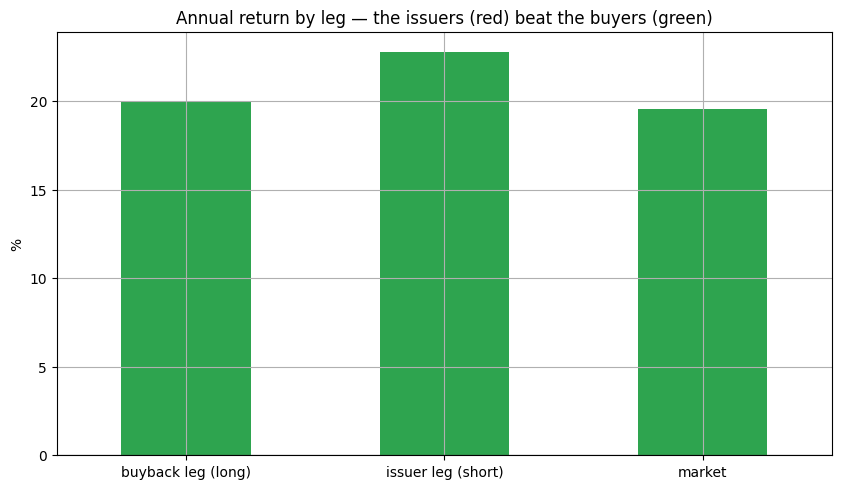

In [2]:
legs = pd.DataFrame({'buyback leg (long)': st.summary(h['low'])['mean'],
                     'issuer leg (short)': st.summary(h['high'])['mean'],
                     'market': st.summary(st.market_annual(fwd).reindex(h.index))['mean']},
                    index=['annual return'])
ax=(legs.T*100).plot.bar(rot=0,legend=False,color=['#2ea44f','#c0392b','#8b949e'],
    title='Annual return by leg — the issuers (red) beat the buyers (green)')
ax.set_ylabel('%'); ax.axhline(0,color='k',lw=.8); plt.show()

## 4 · The teardown — the sign is backwards

The hedge that's *supposed* to pay (long buyers, short issuers) lost money, and lost it in nearly three-quarters of years.

hedge (long buyback, short issuer): -2.83%/yr  Sharpe -0.30  (t~-1.3)  hit 28%


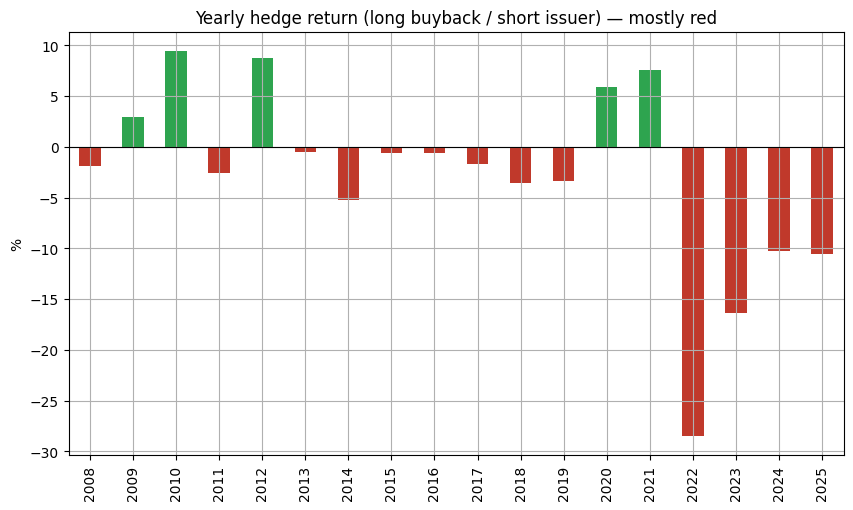

In [3]:
s=st.summary(h['hedge'])
print(f"hedge (long buyback, short issuer): {s['mean']:+.2%}/yr  Sharpe {s['sharpe']:.2f}  (t~{s['tstat']:.1f})  hit {s['hit_rate']:.0%}")
(h['hedge']*100).plot.bar(color=['#2ea44f' if v>0 else '#c0392b' for v in h['hedge']],
    title='Yearly hedge return (long buyback / short issuer) — mostly red')
plt.ylabel('%'); plt.axhline(0,color='k',lw=.8); plt.show()

**Read it plainly.** Over 2010–2025 the heaviest large-cap "issuers" were the growth/tech winners diluting through stock-based comp and acquisitions — exactly the names that led the market. Punishing dilution meant shorting the winners.

## 5 · The verdict

**Signal: Weak** — it inverts (−2.8%/yr, t −1.3). **Tradability: Mirage** — wrong sign on liquid names. **Issuance anomaly on tradable large caps?: Not supported.** The real effect lives in small caps.

## 6 · Could you actually trade it?

Not as built. The published anomaly is strongest in small, illiquid names (secondary offerings, distressed dilution) — the untradable end of the market. On the large caps you can size into, survivorship and the post-2009 growth regime flip its sign. A real factor, in the wrong universe.

## 7 · Going further 🚪

The issuance sibling of [44 Growth-Spurt](../../44-growth-spurt/) (asset growth) and a fundamental cousin of [52 Smoke-Screen](../../52-smoke-screen/) (accruals, which *does* replicate). Forks: micro-cap universe, value-weighting, composite issuance.